#**Delhivery - Feature Engineering**

#Problem Statement

Delhivery is the largest and fastest-growing fully integrated player in India by revenue in Fiscal 2021. They aim to build the operating system for commerce, through a combination of world-class infrastructure, logistics operations of the highest quality, and cutting-edge engineering and technology capabilities.

The Data team builds intelligence and capabilities using this data that helps them to widen the gap between the quality, efficiency, and profitability of their business versus their competitors.

The company wants to understand and process the data coming out of data engineering pipelines:

• Clean, sanitize and manipulate data to get useful features out of raw fields

• Make sense out of the raw data and help the data science team to build forecasting models on it

#Importing Data and Python Libraries

In [506]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_rel

from sklearn.preprocessing import StandardScaler

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

In [507]:
!wget https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/551/original/delhivery_data.csv?1642751181 -O final.csv

--2026-05-27 19:45:35--  https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/551/original/delhivery_data.csv?1642751181
Resolving d2beiqkhq929f0.cloudfront.net (d2beiqkhq929f0.cloudfront.net)... 13.225.41.18, 13.225.41.124, 13.225.41.5, ...
Connecting to d2beiqkhq929f0.cloudfront.net (d2beiqkhq929f0.cloudfront.net)|13.225.41.18|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 55617130 (53M) [text/plain]
Saving to: ‘final.csv’

final.csv           100%[===================>]  53.04M   153MB/s    in 0.3s    

2026-05-27 19:45:36 (153 MB/s) - ‘final.csv’ saved [55617130/55617130]



In [508]:
df = pd.read_csv('/content/final.csv')

In [509]:
df.head()

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:27:55,10.435660,14.0,11.0,11.9653,1.272727,14.0,11.0,11.9653,1.272727
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:17:55,18.936842,24.0,20.0,21.7243,1.200000,10.0,9.0,9.7590,1.111111
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:01:19.505586,27.637279,40.0,28.0,32.5395,1.428571,16.0,7.0,10.8152,2.285714
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:39:57,36.118028,62.0,40.0,45.5620,1.550000,21.0,12.0,13.0224,1.750000
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:33:55,39.386040,68.0,44.0,54.2181,1.545455,6.0,5.0,3.9153,1.200000


In [510]:
df.shape

(144867, 24)

**Observation:**

The dataset contains 144867 rows and 24 columns, indicating a large shipment-level logistics dataset with multiple operational variables.

In [511]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   data                            144867 non-null  object 
 1   trip_creation_time              144867 non-null  object 
 2   route_schedule_uuid             144867 non-null  object 
 3   route_type                      144867 non-null  object 
 4   trip_uuid                       144867 non-null  object 
 5   source_center                   144867 non-null  object 
 6   source_name                     144574 non-null  object 
 7   destination_center              144867 non-null  object 
 8   destination_name                144606 non-null  object 
 9   od_start_time                   144867 non-null  object 
 10  od_end_time                     144867 non-null  object 
 11  start_scan_to_end_scan          144867 non-null  float64
 12  is_cutoff       

**Observation:**

The dataset contains 144867 records and 24 columns consisting of categorical, numerical, boolean, and datetime-related features.

Most columns do not contain missing values. However, source_name and destination_name contain a small number of null values, which will require treatment during data cleaning.

The dataset also contains multiple object-type columns that can later be optimized into categorical and datetime formats for improved memory efficiency and analysis.

In [512]:
df.describe()

,start_scan_to_end_scan,cutoff_factor,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
count,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.00000,144867.000000
mean,961.262986,232.926567,234.073372,416.927527,213.868272,284.771297,2.120107,36.196111,18.507548,22.82902,2.218368
std,1037.012769,344.755577,344.990009,598.103621,308.011085,421.119294,1.715421,53.571158,14.775960,17.86066,4.847530
min,20.000000,9.000000,9.000045,9.000000,6.000000,9.008200,0.144000,-244.000000,0.000000,0.00000,-23.444444
25%,161.000000,22.000000,23.355874,51.000000,27.000000,29.914700,1.604264,20.000000,11.000000,12.07010,1.347826
50%,449.000000,66.000000,66.126571,132.000000,64.000000,78.525800,1.857143,29.000000,17.000000,23.51300,1.684211
75%,1634.000000,286.000000,286.708875,513.000000,257.000000,343.193250,2.213483,40.000000,22.000000,27.81325,2.250000
max,7898.000000,1927.000000,1927.447705,4532.000000,1686.000000,2326.199100,77.387097,3051.000000,1611.000000,2191.40370,574.250000


**Observation:**

Several numerical variables such as actual_time, osrm_time, and osrm_distance show large standard deviations and wide ranges between minimum and maximum values.

The presence of extremely high maximum values compared to median values indicates potential outliers and right-skewed distributions in operational delivery metrics.

Negative values observed in segment_actual_time and segment_factor may indicate data inconsistencies or exceptional operational cases that require further investigation.

In [513]:
df.isnull().sum()

,0
data,0
trip_creation_time,0
route_schedule_uuid,0
route_type,0
trip_uuid,0
source_center,0
source_name,293
destination_center,0
destination_name,261
od_start_time,0


**Observation:**

Missing values are present only in source_name and destination_name columns, with 293 and 261 missing entries respectively.

Since the proportion of missing values is extremely small compared to the overall dataset size, these values can be treated without causing major information loss.

The remaining columns do not contain any missing values, indicating strong overall data completeness.

In [514]:
df.duplicated().sum()

np.int64(0)

**Observation:**

No duplicate rows were found in the dataset, indicating that each shipment-segment record is uniquely captured.

# Data Type Conversion

Convert datetime columns

In [515]:
datetime_cols = ['trip_creation_time',
                 'od_start_time',
                 'od_end_time']

for col in datetime_cols:
    df[col] = pd.to_datetime(df[col])

Convert categorical columns

In [516]:
cat_cols = ['data','route_type']

for col in cat_cols:
    df[col] = df[col].astype('category')

In [517]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   data                            144867 non-null  category      
 1   trip_creation_time              144867 non-null  datetime64[ns]
 2   route_schedule_uuid             144867 non-null  object        
 3   route_type                      144867 non-null  category      
 4   trip_uuid                       144867 non-null  object        
 5   source_center                   144867 non-null  object        
 6   source_name                     144574 non-null  object        
 7   destination_center              144867 non-null  object        
 8   destination_name                144606 non-null  object        
 9   od_start_time                   144867 non-null  datetime64[ns]
 10  od_end_time                     144867 non-null  datetim

**Observation:**

Datetime and categorical conversions improve memory efficiency and simplify temporal and categorical analysis in later stages of the project.

Dropping Unknown or Irrelevant Features

In [518]:
unknown_cols = ['is_cutoff',
                'cutoff_factor',
                'cutoff_timestamp',
                'factor',
                'segment_factor']

df.drop(columns=unknown_cols, inplace=True)

In [519]:
df.shape

(144867, 19)

**Observation:**

Columns with unclear business meaning or limited interpretability were removed to improve analytical clarity and reduce unnecessary complexity.

Missing Value Treatment

In [520]:
df.isnull().sum()

,0
data,0
trip_creation_time,0
route_schedule_uuid,0
route_type,0
trip_uuid,0
source_center,0
source_name,293
destination_center,0
destination_name,261
od_start_time,0


Create mapping for source names

In [521]:
source_mapping = (df.groupby('source_center')
['source_name'].first())

Create mapping for destination names

In [522]:
destination_mapping = (df.groupby('destination_center')
['destination_name'].first())

Fill missing source names

In [523]:
df['source_name'] = df['source_name'].fillna(
df['source_center'].map(source_mapping))

Fill missing destination names

In [524]:
df['destination_name'] = df['destination_name'].fillna(
df['destination_center'].map(destination_mapping))

Remaining nulls

In [525]:
df['source_name'] = df['source_name'].fillna('Unknown')
df['destination_name'] = df['destination_name'].fillna('Unknown')

In [526]:
df.isnull().sum()

,0
data,0
trip_creation_time,0
route_schedule_uuid,0
route_type,0
trip_uuid,0
source_center,0
source_name,0
destination_center,0
destination_name,0
od_start_time,0


**Observation:**

Missing location names were treated using center-based mapping to preserve business consistency and minimize information loss.

# Feature Engineering from Location Data

Extracting Source & Destination of State

In [527]:
df['source_state'] = df['source_name'].str.extract(r'\((.*)\)')

In [528]:
df['destination_state'] = df['destination_name'].str.extract(r'\((.*)\)')

Extracting Source & Destination of City

In [529]:
df['source_city'] = df['source_name'].str.split('_').str[0]

In [530]:
df['destination_city'] = df['destination_name'].str.split('_').str[0]

In [531]:
df[['source_name',
    'source_city',
    'source_state']].head()

,source_name,source_city,source_state
0,Anand_VUNagar_DC (Gujarat),Anand,Gujarat
1,Anand_VUNagar_DC (Gujarat),Anand,Gujarat
2,Anand_VUNagar_DC (Gujarat),Anand,Gujarat
3,Anand_VUNagar_DC (Gujarat),Anand,Gujarat
4,Anand_VUNagar_DC (Gujarat),Anand,Gujarat


**Observation:**

City and state-level features were extracted from shipment location names to enable corridor-level and regional logistics analysis.

# Time-Based Feature Engineering

In [532]:
df['trip_month'] = df['trip_creation_time'].dt.month

In [533]:
df['trip_day'] = df['trip_creation_time'].dt.day

In [534]:
df['trip_hour'] = df['trip_creation_time'].dt.hour

In [535]:
df['trip_weekday'] = (df['trip_creation_time'].dt.day_name())

In [536]:
df[['trip_creation_time',
    'trip_month',
    'trip_day',
    'trip_hour',
    'trip_weekday']].head()

,trip_creation_time,trip_month,trip_day,trip_hour,trip_weekday
0,2018-09-20 02:35:36.476840,9,20,2,Thursday
1,2018-09-20 02:35:36.476840,9,20,2,Thursday
2,2018-09-20 02:35:36.476840,9,20,2,Thursday
3,2018-09-20 02:35:36.476840,9,20,2,Thursday
4,2018-09-20 02:35:36.476840,9,20,2,Thursday


**Observation:**

Temporal features such as month, day, hour, and weekday were extracted to analyze operational delivery patterns across different time periods.

# Trip Duration Feature

In [537]:
df['od_time_diff'] = (df['od_end_time'] -
                      df['od_start_time']).dt.total_seconds()/60

In [538]:
df[['od_start_time',
    'od_end_time',
    'od_time_diff']].head()

,od_start_time,od_end_time,od_time_diff
0,2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.213637
1,2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.213637
2,2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.213637
3,2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.213637
4,2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.213637


**Observation:**

A new feature representing total trip duration in minutes was created using origin-destination timestamps.

# Understanding Shipment Segmentation

Each trip in the dataset is divided into multiple shipment segments. Therefore, multiple rows may belong to the same trip.

To perform meaningful operational analysis, shipment-segment records must be aggregated into trip-level records by combining cumulative metrics while preserving key identifying information.

# Aggregating Shipment Segments

In [539]:
group_cols = ['trip_uuid',
              'source_center',
              'destination_center']

In [540]:
agg_dict = {'actual_time':'last',
            'osrm_time':'last',
            'osrm_distance':'last',

            'segment_actual_time':'sum',
            'segment_osrm_time':'sum',
            'segment_osrm_distance':'sum',

            'trip_creation_time':'first',
            'route_type':'first',

            'source_name':'first',
            'destination_name':'last',

            'source_state':'first',
            'destination_state':'last',

            'source_city':'first',
            'destination_city':'last',

            'od_start_time':'first',
            'od_end_time':'last',

            'start_scan_to_end_scan':'first',
            'od_time_diff':'first'}

In [541]:
df_grouped = (df.groupby(group_cols).agg(agg_dict).reset_index())

In [542]:
df_grouped.shape

(26368, 21)

In [543]:
df_grouped.head()

,trip_uuid,source_center,destination_center,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance,trip_creation_time,...,source_name,destination_name,source_state,destination_state,source_city,destination_city,od_start_time,od_end_time,start_scan_to_end_scan,od_time_diff
0,trip-153671041653548748,IND209304AAA,IND000000ACB,732.0,329.0,446.5496,728.0,534.0,670.6205,2018-09-12 00:00:16.535741,...,Kanpur_Central_H_6 (Uttar Pradesh),Gurgaon_Bilaspur_HB (Haryana),Uttar Pradesh,Haryana,Kanpur,Gurgaon,2018-09-12 16:39:46.858469,2018-09-13 13:40:23.123744,1260.0,1260.604421
1,trip-153671041653548748,IND462022AAA,IND209304AAA,830.0,388.0,544.8027,820.0,474.0,649.8528,2018-09-12 00:00:16.535741,...,Bhopal_Trnsport_H (Madhya Pradesh),Kanpur_Central_H_6 (Uttar Pradesh),Madhya Pradesh,Uttar Pradesh,Bhopal,Kanpur,2018-09-12 00:00:16.535741,2018-09-12 16:39:46.858469,999.0,999.505379
2,trip-153671042288605164,IND561203AAB,IND562101AAA,47.0,26.0,28.1994,46.0,26.0,28.1995,2018-09-12 00:00:22.886430,...,Doddablpur_ChikaDPP_D (Karnataka),Chikblapur_ShntiSgr_D (Karnataka),Karnataka,Karnataka,Doddablpur,Chikblapur,2018-09-12 02:03:09.655591,2018-09-12 03:01:59.598855,58.0,58.832388
3,trip-153671042288605164,IND572101AAA,IND561203AAB,96.0,42.0,56.9116,95.0,39.0,55.9899,2018-09-12 00:00:22.886430,...,Tumkur_Veersagr_I (Karnataka),Doddablpur_ChikaDPP_D (Karnataka),Karnataka,Karnataka,Tumkur,Doddablpur,2018-09-12 00:00:22.886430,2018-09-12 02:03:09.655591,122.0,122.779486
4,trip-153671043369099517,IND000000ACB,IND160002AAC,611.0,212.0,281.2109,608.0,231.0,317.7408,2018-09-12 00:00:33.691250,...,Gurgaon_Bilaspur_HB (Haryana),Chandigarh_Mehmdpur_H (Punjab),Haryana,Punjab,Gurgaon,Chandigarh,2018-09-14 03:40:17.106733,2018-09-14 17:34:55.442454,834.0,834.638929


**Observation:**

Shipment-segment records were aggregated into route-level operational records by preserving cumulative trip metrics using the final recorded values and summing segment-level operational metrics.

# Trip-Level Aggregation

In [544]:
trip_agg = {'actual_time':'sum',
            'osrm_time':'sum',
            'osrm_distance':'sum',

            'segment_actual_time':'sum',
            'segment_osrm_time':'sum',
            'segment_osrm_distance':'sum',

            'start_scan_to_end_scan':'sum',
            'od_time_diff':'sum',

            'trip_creation_time':'first',
            'route_type':'first',

            'source_name':'first',
            'destination_name':'last',

            'source_state':'first',
            'destination_state':'last',

            'source_city':'first',
            'destination_city':'last'}

In [545]:
trip_df = (df_grouped.groupby('trip_uuid').agg(trip_agg).reset_index())

In [546]:
trip_df.shape

(14817, 17)

In [547]:
trip_df.head()

,trip_uuid,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance,start_scan_to_end_scan,od_time_diff,trip_creation_time,route_type,source_name,destination_name,source_state,destination_state,source_city,destination_city
0,trip-153671041653548748,1562.0,717.0,991.3523,1548.0,1008.0,1320.4733,2259.0,2260.109800,2018-09-12 00:00:16.535741,FTL,Kanpur_Central_H_6 (Uttar Pradesh),Kanpur_Central_H_6 (Uttar Pradesh),Uttar Pradesh,Uttar Pradesh,Kanpur,Kanpur
1,trip-153671042288605164,143.0,68.0,85.1110,141.0,65.0,84.1894,180.0,181.611874,2018-09-12 00:00:22.886430,Carting,Doddablpur_ChikaDPP_D (Karnataka),Doddablpur_ChikaDPP_D (Karnataka),Karnataka,Karnataka,Doddablpur,Doddablpur
2,trip-153671043369099517,3347.0,1740.0,2354.0665,3308.0,1941.0,2545.2678,3933.0,3934.362520,2018-09-12 00:00:33.691250,FTL,Gurgaon_Bilaspur_HB (Haryana),Gurgaon_Bilaspur_HB (Haryana),Haryana,Haryana,Gurgaon,Gurgaon
3,trip-153671046011330457,59.0,15.0,19.6800,59.0,16.0,19.8766,100.0,100.494935,2018-09-12 00:01:00.113710,Carting,Mumbai Hub (Maharashtra),Mumbai_MiraRd_IP (Maharashtra),Maharashtra,Maharashtra,Mumbai Hub (Maharashtra),Mumbai
4,trip-153671052974046625,341.0,117.0,146.7918,340.0,115.0,146.7919,717.0,718.349042,2018-09-12 00:02:09.740725,FTL,Bellary_Dc (Karnataka),Sandur_WrdN1DPP_D (Karnataka),Karnataka,Karnataka,Bellary,Sandur


**Observation:**

Route-level shipment records were further aggregated into trip-level operational records to enable complete end-to-end logistics analysis.

# Delivery Performance Feature Engineering

Time Difference Feature

In [548]:
trip_df['time_difference'] = (
trip_df['actual_time'] - trip_df['osrm_time'])

Delay Ratio Feature

In [549]:
trip_df['delay_ratio'] = (
trip_df['actual_time'] / trip_df['osrm_time'])

Actual Speed

In [550]:
trip_df['actual_speed'] = (
trip_df['osrm_distance'] / (trip_df['actual_time']/60))

OSRM Speed

In [551]:
trip_df['osrm_speed'] = (
trip_df['osrm_distance'] / (trip_df['osrm_time']/60))

In [552]:
trip_df[['actual_time',
         'osrm_time',
         'time_difference',
         'delay_ratio',
         'actual_speed',
         'osrm_speed']].head()

,actual_time,osrm_time,time_difference,delay_ratio,actual_speed,osrm_speed
0,1562.0,717.0,845.0,2.178522,38.080114,82.958351
1,143.0,68.0,75.0,2.102941,35.710909,75.097941
2,3347.0,1740.0,1607.0,1.923563,42.200176,81.174707
3,59.0,15.0,44.0,3.933333,20.013559,78.720000
4,341.0,117.0,224.0,2.914530,25.828469,75.277846


**Observation:**

Additional delivery performance features were created to evaluate operational delays, estimated-versus-actual delivery efficiency, and average transportation speeds across trips.

# Univariate Analysis

1. Distribution Plot - Actual Delivery Time

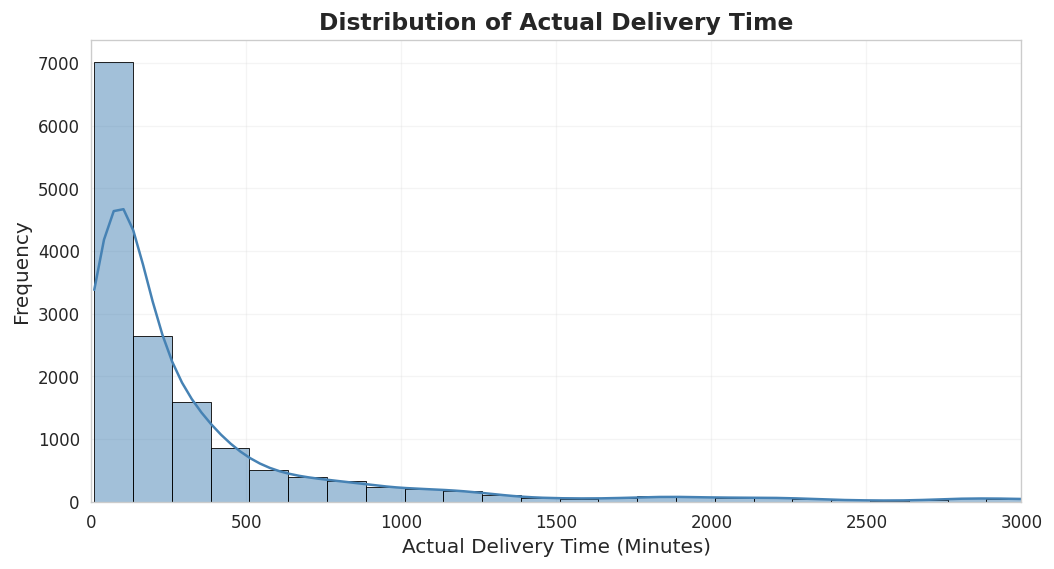

In [553]:
plt.figure(figsize=(10,5))

sns.histplot(
    trip_df['actual_time'],
    bins=50,
    kde=True,
    color='steelblue',
    edgecolor='black',
    linewidth=0.5
)

plt.xlim(0, 3000)

plt.title(
    'Distribution of Actual Delivery Time',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Actual Delivery Time (Minutes)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.grid(alpha=0.2)

plt.show()

**Observation:**

- Most deliveries are completed within 500 minutes, indicating that Delhivery’s operations are primarily concentrated in short and medium-haul logistics routes.
- The distribution is heavily right-skewed, with a small number of trips extending beyond 2000 minutes, representing operationally difficult or long-haul deliveries.
- The long tail suggests the presence of substantial delivery-time variability across corridors.

2. Distribution of OSRM Estimated Time

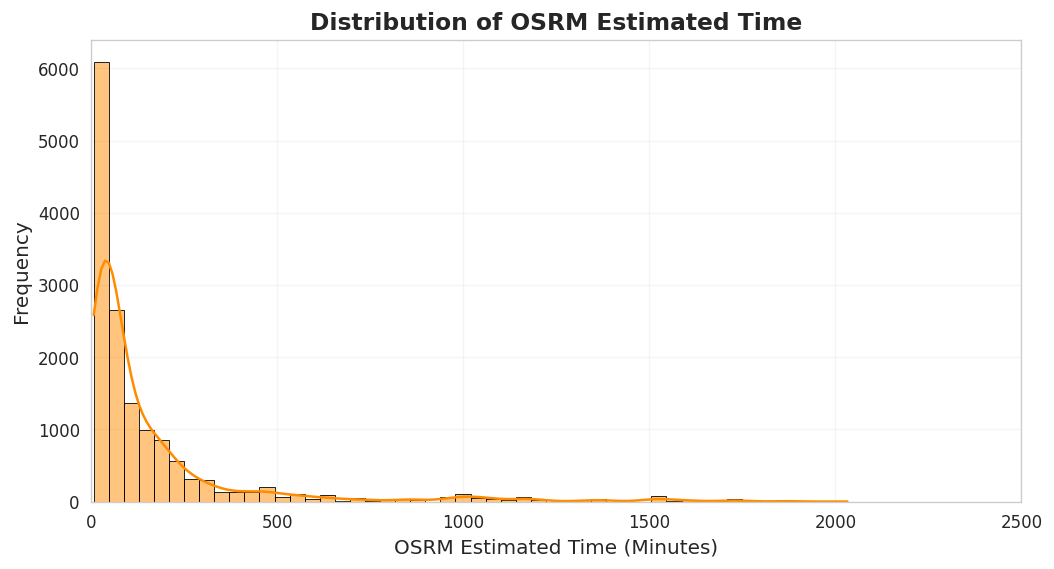

In [554]:
plt.figure(figsize=(10,5))

sns.histplot(
    trip_df['osrm_time'],
    bins=50,
    kde=True,
    color='darkorange',
    edgecolor='black',
    linewidth=0.5
)

plt.xlim(0, 2500)

plt.title(
    'Distribution of OSRM Estimated Time',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('OSRM Estimated Time (Minutes)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.grid(alpha=0.2)

plt.show()

**Observation:**

- OSRM estimated delivery times are strongly concentrated below 400 minutes, showing that the majority of predicted routes are relatively short.
- The estimated-time distribution is smoother and less dispersed than actual delivery time, indicating that real-world operational uncertainty increases delivery variability.
- A small number of extremely long predicted routes create the extended right tail.

3. Distribution of OSRM Distance

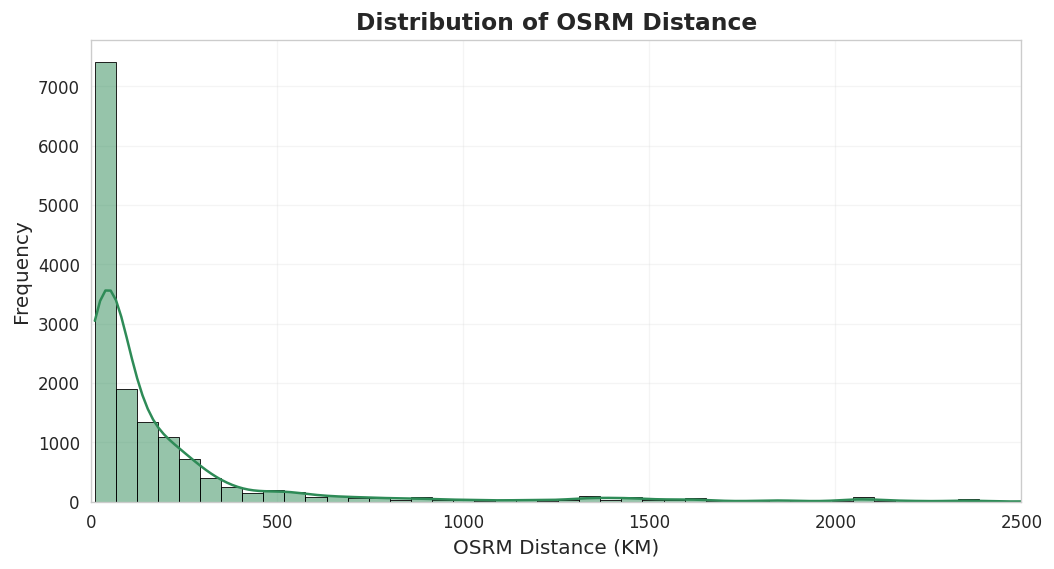

In [555]:
plt.figure(figsize=(10,5))

sns.histplot(
    trip_df['osrm_distance'],
    bins=50,
    kde=True,
    color='seagreen',
    edgecolor='black',
    linewidth=0.5
)

plt.xlim(0, 2500)

plt.title(
    'Distribution of OSRM Distance',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('OSRM Distance (KM)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.grid(alpha=0.2)

plt.show()

**Observation:**

- Most delivery routes fall below 500 km, indicating that Delhivery’s logistics network is dominated by short and medium-distance shipment corridors.
- Only a limited number of trips exceed 1500 km, representing long-haul inter-state logistics operations.
- The strong right-skewness highlights significant variation in corridor distances across the network.

4. Distribution of Segment Actual Time

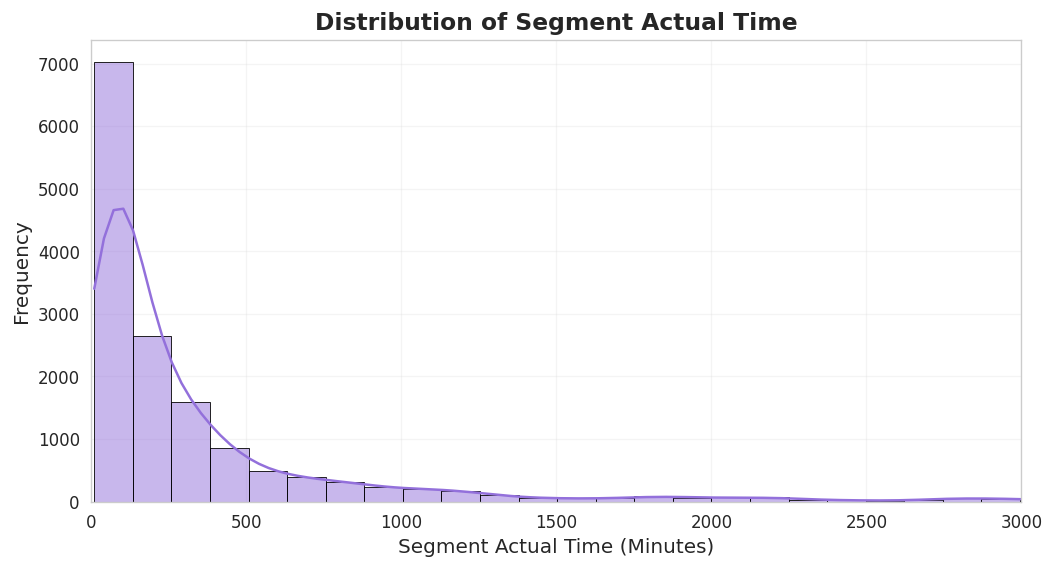

In [556]:
plt.figure(figsize=(10,5))

sns.histplot(
    trip_df['segment_actual_time'],
    bins=50,
    kde=True,
    color='mediumpurple',
    edgecolor='black',
    linewidth=0.5
)

plt.xlim(0, 3000)

plt.title(
    'Distribution of Segment Actual Time',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Segment Actual Time (Minutes)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.grid(alpha=0.2)

plt.show()

**Observation:**

- Most shipment segments are completed within relatively low delivery durations, indicating efficient execution across standard operational segments.
- However, a smaller number of segment deliveries experience extremely high completion times, contributing to the pronounced right tail.
- The distribution suggests that operational bottlenecks are concentrated within a minority of difficult shipment segments rather than across the overall network.

# Outlier Analysis

1. Boxplot - Actual Time

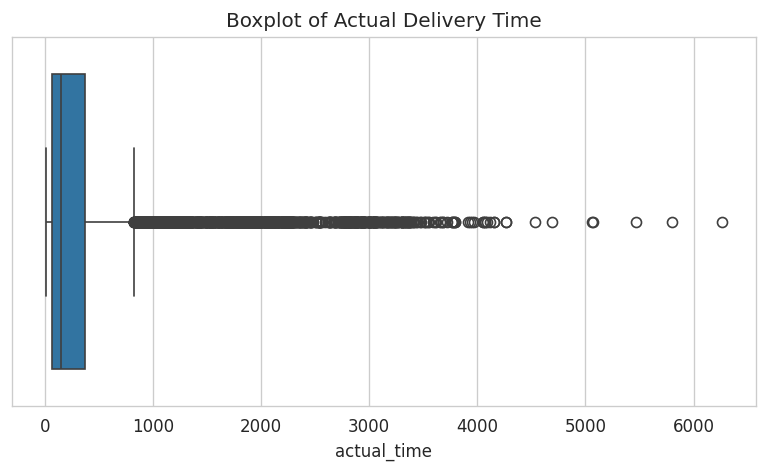

In [557]:
plt.figure(figsize=(8,4))

sns.boxplot(x=trip_df['actual_time'])

plt.title('Boxplot of Actual Delivery Time')

plt.show()

2. Boxplot — OSRM Time

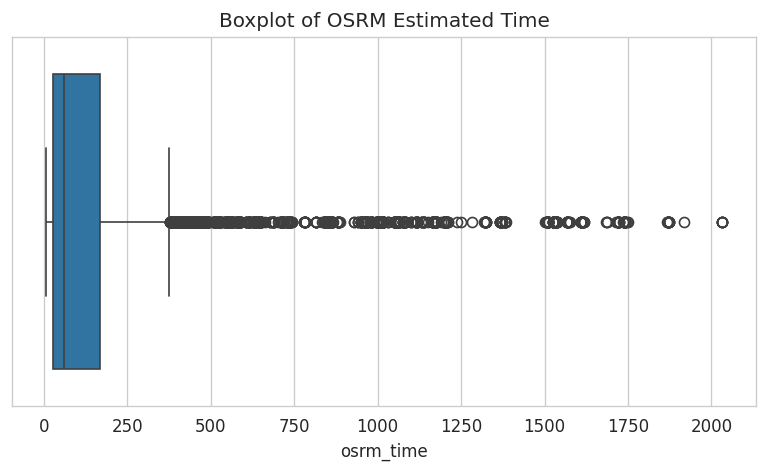

In [558]:
plt.figure(figsize=(8,4))

sns.boxplot(x=trip_df['osrm_time'])

plt.title('Boxplot of OSRM Estimated Time')

plt.show()

3. Boxplot — OSRM Distance

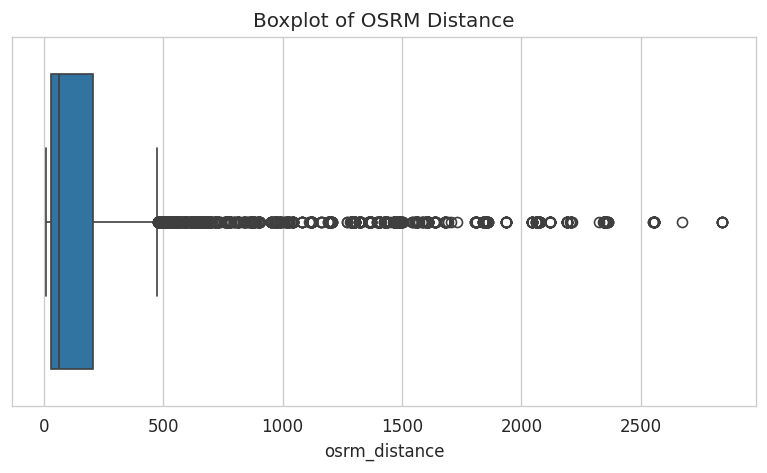

In [559]:
plt.figure(figsize=(8,4))

sns.boxplot(x=trip_df['osrm_distance'])

plt.title('Boxplot of OSRM Distance')

plt.show()

4. Boxplot — Actual Speed

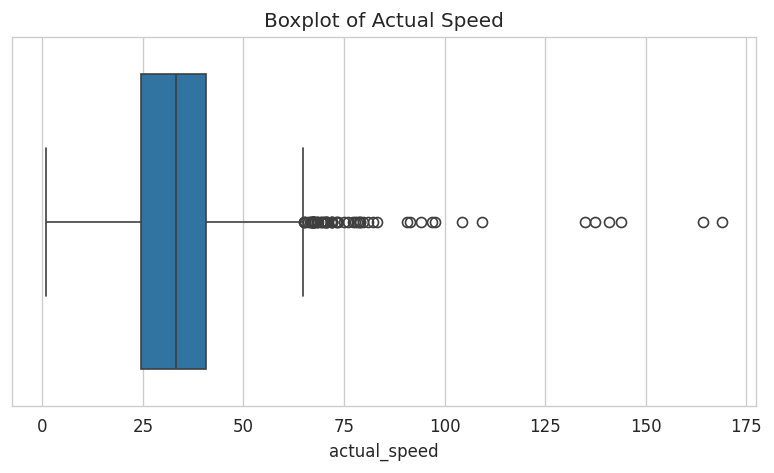

In [560]:
plt.figure(figsize=(8,4))

sns.boxplot(x=trip_df['actual_speed'])

plt.title('Boxplot of Actual Speed')

plt.show()

**Observation:**

- All major operational metrics contain substantial outliers, particularly actual_time and osrm_distance.
- Several trips exhibit exceptionally high delivery durations and route distances compared to the majority of observations, indicating operational disruptions, traffic congestion, or unusually long-haul delivery corridors.

# Bivariate Analysis

1. Scatterplot — Actual Time vs OSRM Time

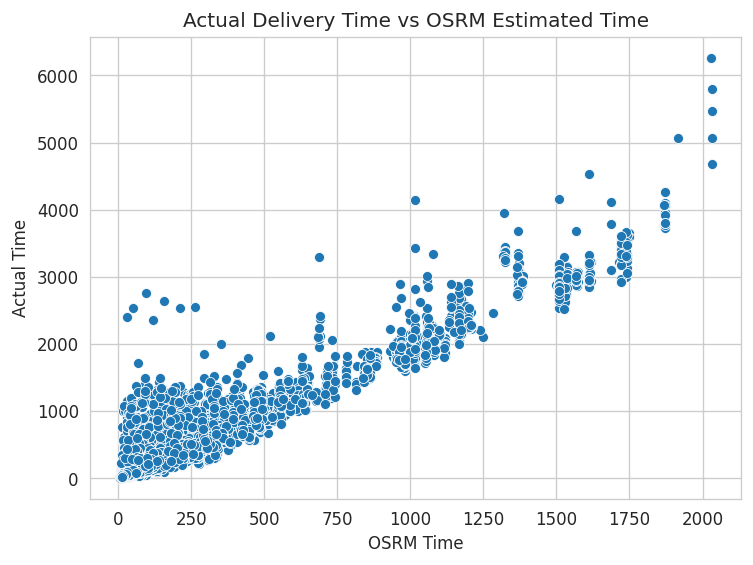

In [561]:
plt.figure(figsize=(7,5))

sns.scatterplot(x='osrm_time',
                y='actual_time',
                data=trip_df)

plt.title('Actual Delivery Time vs OSRM Estimated Time')

plt.xlabel('OSRM Time')
plt.ylabel('Actual Time')

plt.show()

**Observation:**

- Actual delivery time increases strongly with OSRM estimated time, confirming that routing estimates are directionally accurate.
- However, most observations lie above the ideal equality pattern, indicating that real-world deliveries consistently take longer than predicted route estimates.

2. Scatterplot — OSRM Distance vs Actual Time

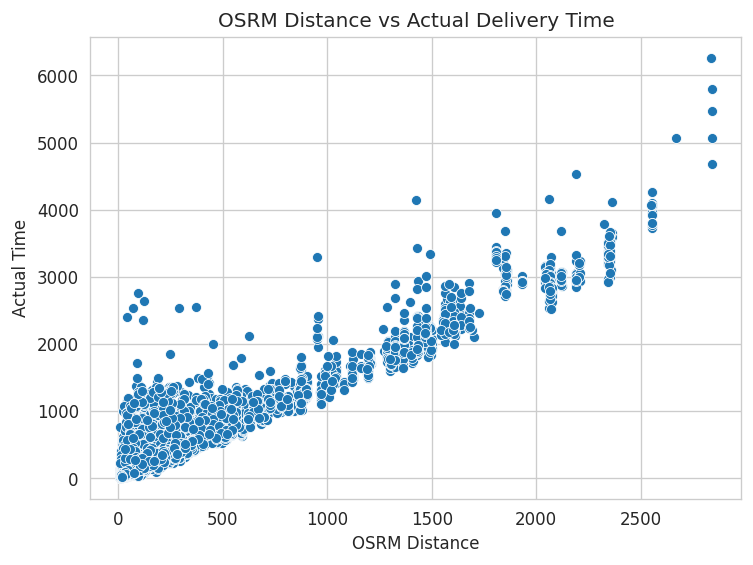

In [562]:
plt.figure(figsize=(7,5))

sns.scatterplot(x='osrm_distance',
                y='actual_time',
                data=trip_df)

plt.title('OSRM Distance vs Actual Delivery Time')

plt.xlabel('OSRM Distance')
plt.ylabel('Actual Time')

plt.show()

**Observation:**

- Delivery duration rises steadily with route distance, showing a strong operational relationship between travel distance and completion time.
- Longer routes also exhibit greater variability in delivery duration, suggesting increasing operational uncertainty for long-haul trips.

# Correlation Analysis

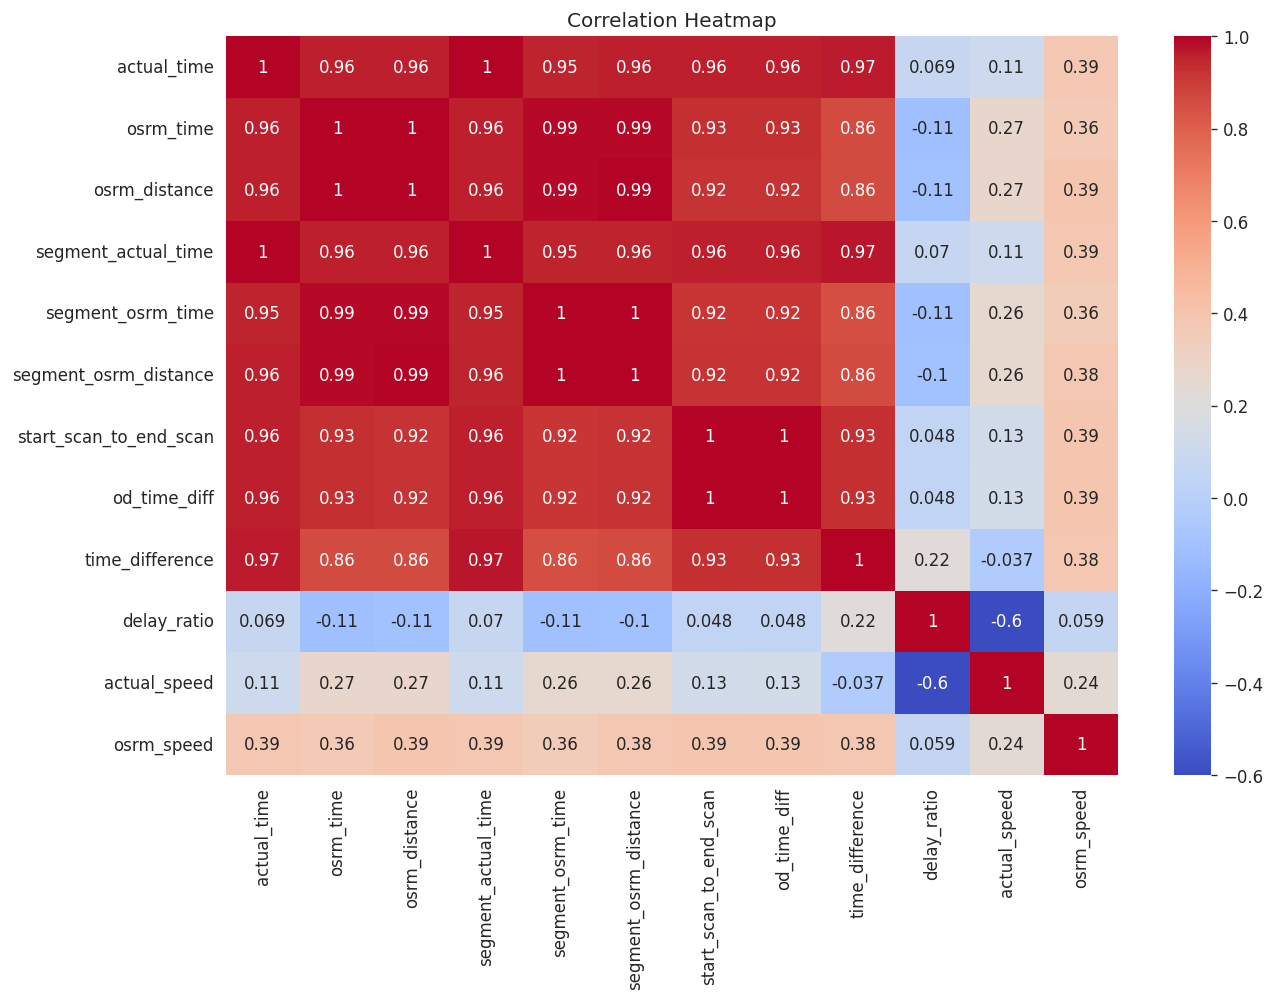

In [563]:
plt.figure(figsize=(12,8))

corr = trip_df.select_dtypes(include=np.number).corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

**Observation:**

- 'actual_time' shows extremely strong positive correlations with osrm_time, osrm_distance, and segment-level metrics, indicating that route distance and estimated travel duration are primary drivers of delivery performance.
- 'delay_ratio' shows a negative correlation with actual_speed, suggesting that slower trips tend to experience proportionally higher delays.

# Hypothesis Testing

1. Actual Delivery Time vs OSRM Estimated Time

Null Hypothesis (H0):

There is no significant difference between actual delivery time and OSRM estimated delivery time.

Alternate Hypothesis (H1):

There is a significant difference between actual delivery time and OSRM estimated delivery time.

In [564]:
from scipy.stats import ttest_rel

stat, p_value = ttest_rel(trip_df['actual_time'], trip_df['osrm_time'])

print('T-statistic:', stat)
print('P-value:', p_value)

T-statistic: 76.61411942262393
P-value: 0.0


Conclusion:

Since the p-value is less than 0.05, we reject the null hypothesis.

This indicates a statistically significant difference between actual delivery time and OSRM estimated delivery time. The result suggests that real-world delivery operations differ considerably from route-based estimated delivery times, likely due to traffic conditions, operational delays, and logistical inefficiencies.

2. Actual Delivery Time vs Segment Actual Time

Null Hypothesis (H0):

There is no significant difference between aggregated actual delivery time and aggregated segment actual time.

Alternate Hypothesis (H1):

There is a significant difference between aggregated actual delivery time and aggregated segment actual time.

In [565]:
stat, p_value = ttest_rel(trip_df['actual_time'],
trip_df['segment_actual_time'])

print('T-statistic:', stat)
print('P-value:', p_value)

T-statistic: 68.46429609754104
P-value: 0.0


Conclusion:

Since the p-value is less than 0.05, we reject the null hypothesis.

This indicates a statistically significant difference between aggregated actual delivery time and aggregated segment actual time. The result suggests that operational variations exist across delivery segments and overall trip execution.

3. OSRM Distance vs Segment OSRM Distance

Null Hypothesis (H0):

There is no significant difference between aggregated OSRM distance and aggregated segment OSRM distance.

Alternate Hypothesis (H1):

There is a significant difference between aggregated OSRM distance and aggregated segment OSRM distance.

In [566]:
stat, p_value = ttest_rel(trip_df['osrm_distance'],
trip_df['segment_osrm_distance'])

print('T-statistic:', stat)
print('P-value:', p_value)

T-statistic: -37.381312117726914
P-value: 2.419297272724162e-292


Conclusion:

Since the p-value is less than 0.05, we reject the null hypothesis.

This indicates a statistically significant difference between aggregated OSRM distance and aggregated segment OSRM distance. The result suggests that segment-level route calculations differ meaningfully from overall aggregated route estimates.

4. OSRM Time vs Segment OSRM Time

Null Hypothesis (H0):

There is no significant difference between aggregated OSRM time and aggregated segment OSRM time.

Alternate Hypothesis (H1):

There is a significant difference between aggregated OSRM time and aggregated segment OSRM time.

In [567]:
stat, p_value = ttest_rel(trip_df['osrm_time'],
trip_df['segment_osrm_time'])

print('T-statistic:', stat)
print('P-value:', p_value)

T-statistic: -43.37186612146427
P-value: 0.0


Conclusion:

Since the p-value is less than 0.05, we reject the null hypothesis.

This indicates a statistically significant difference between aggregated OSRM time and aggregated segment OSRM time. The result suggests that segment-level routing estimates vary significantly from overall trip-level estimated delivery durations.

5. OD Time Difference vs Start Scan to End Scan

Null Hypothesis (H0):

There is no significant difference between od_time_diff and start_scan_to_end_scan.

Alternate Hypothesis (H1):

There is a significant difference between od_time_diff and start_scan_to_end_scan.

In [568]:
stat, p_value = ttest_rel(trip_df['od_time_diff'],
trip_df['start_scan_to_end_scan'])

print('T-statistic:', stat)
print('P-value:', p_value)

T-statistic: 153.10149408387232
P-value: 0.0


Conclusion:

Since the p-value is less than 0.05, we reject the null hypothesis.

This indicates a statistically significant difference between od_time_diff and start_scan_to_end_scan, suggesting differences between operational scan durations and actual trip duration calculations.

# Outlier Treatment Using IQR Method

In [569]:
trip_df_clean = trip_df.copy()

In [570]:
def remove_outliers(df, col):

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower_bound) &
        (df[col] <= upper_bound)]

    return df

In [571]:
outlier_cols = ['actual_time',
                'osrm_time',
                'osrm_distance',
                'actual_speed']

In [572]:
for col in outlier_cols:

    trip_df_clean = remove_outliers(trip_df_clean, col)

In [573]:
print("Original Shape:", trip_df.shape)

print("Shape After Outlier Treatment:",
      trip_df_clean.shape)

Original Shape: (14817, 21)
Shape After Outlier Treatment: (11801, 21)


**Observation:**

- Outlier treatment reduced the dataset size from 14817 to 11801 rows, removing extremely abnormal operational trips while preserving the majority of delivery records.
- The post-treatment boxplot shows a substantially tighter distribution with reduced influence from extreme delays.

Before Outlier Treatment

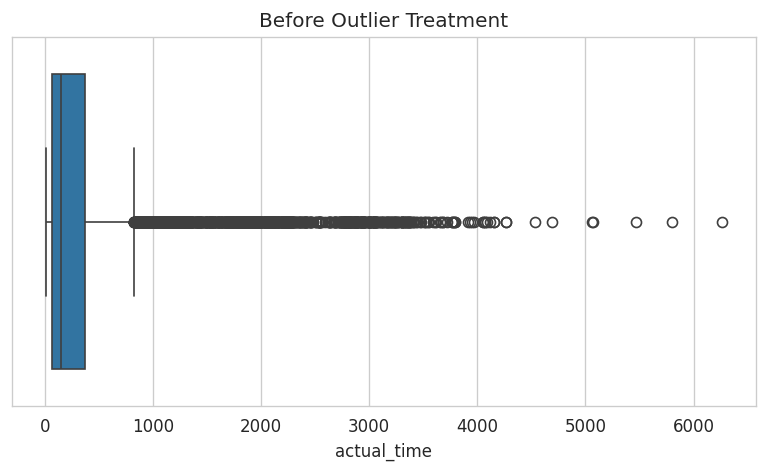

In [574]:
plt.figure(figsize=(8,4))

sns.boxplot(x=trip_df['actual_time'])

plt.title('Before Outlier Treatment')

plt.show()

After Outlier Treatment

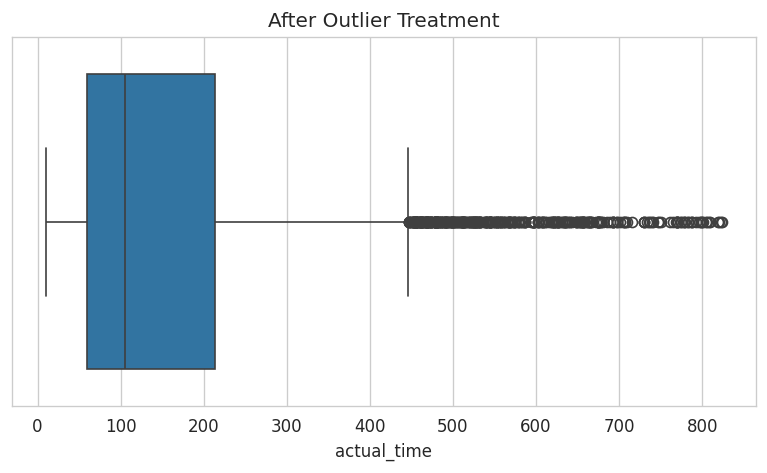

In [575]:
plt.figure(figsize=(8,4))

sns.boxplot(x=trip_df_clean['actual_time'])

plt.title('After Outlier Treatment')

plt.show()

**Observation:**

After outlier treatment, the spread of extreme delivery duration values reduced significantly, resulting in a more compact and analytically stable distribution.

# Handling Categorical Variables

In [576]:
trip_df_encoded = pd.get_dummies(
    trip_df_clean,
    columns=['route_type'],
    drop_first=True)

In [577]:
trip_df_encoded.columns

Index(['trip_uuid', 'actual_time', 'osrm_time', 'osrm_distance',
       'segment_actual_time', 'segment_osrm_time', 'segment_osrm_distance',
       'start_scan_to_end_scan', 'od_time_diff', 'trip_creation_time',
       'source_name', 'destination_name', 'source_state', 'destination_state',
       'source_city', 'destination_city', 'time_difference', 'delay_ratio',
       'actual_speed', 'osrm_speed', 'route_type_FTL'],
      dtype='object')

**Observation:**

The categorical route type feature was converted into numerical format using one-hot encoding, enabling its use in machine learning and statistical analysis.

# Feature Scaling

In [578]:
num_cols = ['actual_time',
            'osrm_time',
            'osrm_distance',
            'segment_actual_time',
            'segment_osrm_time',
            'segment_osrm_distance',
            'actual_speed',
            'osrm_speed',
            'delay_ratio']

In [579]:
from sklearn.preprocessing import StandardScaler

In [580]:
scaler = StandardScaler()

trip_df_encoded[num_cols] = scaler.fit_transform(trip_df_encoded[num_cols])

Scaled Numerical Features

In [581]:
trip_df_encoded[num_cols].head()

,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance,actual_speed,osrm_speed,delay_ratio
1,-0.078503,0.057993,0.157129,-0.083239,-0.109554,0.050853,0.430143,0.733661,-0.283334
3,-0.726022,-0.936714,-0.839565,-0.719043,-0.919889,-0.854094,-0.976295,1.073215,0.650647
4,1.447792,0.977628,1.096698,1.459748,0.717318,0.931734,-0.455295,0.750527,0.130789
5,-0.710605,-0.786570,-0.711843,-0.711289,-0.804127,-0.738879,-0.296157,0.556887,-0.003081
6,-0.995822,-0.974250,-0.956272,-0.990422,-0.969501,-0.964667,-0.077417,-1.106421,-0.414363


**Observation:**

Numerical variables were standardized using StandardScaler to ensure consistent scaling across features and reduce the impact of differing numerical magnitudes.

In [582]:
trip_df_encoded.describe().T

,count,mean,min,25%,50%,75%,max,std
actual_time,11801.0,0.0,-1.103742,-0.726022,-0.371428,0.468805,5.171027,1.000042
osrm_time,11801.0,-0.0,-1.105627,-0.749033,-0.411208,0.545963,3.642692,1.000042
osrm_distance,11801.0,0.0,-1.00114,-0.721589,-0.464946,0.509451,2.924476,1.000042
segment_actual_time,11801.0,0.0,-1.098974,-0.726796,-0.370126,0.467274,5.204787,1.000042
segment_osrm_time,11801.0,0.0,-1.085263,-0.754514,-0.374153,0.518869,5.728163,1.000042
segment_osrm_distance,11801.0,0.0,-1.006113,-0.733127,-0.42159,0.556969,6.64172,1.000042
start_scan_to_end_scan,11801.0,290.017456,23.0,131.0,217.0,372.0,2920.0,236.240186
od_time_diff,11801.0,290.805765,23.461468,131.487092,217.998322,373.25304,2921.545709,236.504486
trip_creation_time,11801,2018-09-22 14:16:56.022492416,2018-09-12 00:00:22.886430,2018-09-17 04:27:17.199638016,2018-09-22 06:09:34.298350080,2018-09-27 22:23:45.342044928,2018-10-03 23:59:42.701692,NaN
time_difference,11801.0,88.273875,-32.0,28.0,57.0,119.0,762.0,92.955101


#Corridor Analysis

In [583]:
trip_df['corridor'] = (
    trip_df['source_state'] +
    ' to ' +
    trip_df['destination_state'])

trip_df['corridor'].value_counts().head(5)

,count
corridor,
Maharashtra to Maharashtra,2453
Karnataka to Karnataka,2057
Tamil Nadu to Tamil Nadu,1021
Haryana to Haryana,949
Telangana to Telangana,689


**Observation:**

Maharashtra to Maharashtra is the busiest logistics corridor with 2453 trips, followed by Karnataka to Karnataka with 2057 trips. This indicates that a significant portion of Delhivery’s operations is concentrated within high-demand intra-state delivery networks.

In [584]:
busiest = trip_df['corridor'].value_counts().idxmax()

busiest_data = trip_df[trip_df['corridor'] == busiest]

print("Busiest Corridor:", busiest)

print("Average Distance:", busiest_data['osrm_distance'].mean())

print("Average Actual Time:", busiest_data['actual_time'].mean())

Busiest Corridor: Maharashtra to Maharashtra
Average Distance: 88.29726812066858
Average Actual Time: 185.14349775784754


**Observation:**

The Maharashtra to Maharashtra corridor records an average OSRM distance of approximately 88 km and an average actual delivery time of 185 minutes, indicating high shipment density primarily across short-distance urban and regional delivery operations.

Route Type Performance Analysis

In [585]:
route_analysis = (trip_df_clean.groupby('route_type',
observed=False)[['delay_ratio', 'time_difference', 'actual_speed']].mean())

route_analysis

,delay_ratio,time_difference,actual_speed
route_type,,,
Carting,2.800746,69.688152,29.105314
FTL,2.254985,140.853018,36.015663


**Observation:**

- Carting routes show a higher average delay ratio (2.80) than FTL routes (2.25), indicating that smaller shipment operations experience relatively greater delays.
- In contrast, FTL routes record higher average time differences because they generally involve longer travel corridors and larger shipment movements.

Most Delayed Corridors

In [586]:
state_corridors = (
    trip_df_clean.groupby(
        ['source_state', 'destination_state']
    )['delay_ratio']
    .agg(['count', 'mean']))

top_delayed_corridors = (
    state_corridors[state_corridors['count'] > 50]
    .sort_values(by='mean', ascending=False)
    .head(5))

top_delayed_corridors

,,count,mean
source_state,destination_state,,
Uttar Pradesh,Delhi,57,3.616716
Madhya Pradesh,Madhya Pradesh,190,3.575724
Assam,Assam,141,3.490378
West Bengal,West Bengal,520,3.426661
Uttar Pradesh,Uttar Pradesh,428,3.412566


**Observation:**

- The Uttar Pradesh to Delhi corridor recorded the highest average delay ratio (3.62) among corridors with significant shipment volume.
- This suggests persistent operational inefficiencies in one of Delhivery’s major North Indian delivery corridors, potentially due to urban congestion, high shipment density, or hub processing delays.

# Business Insights

• Actual delivery times are consistently higher than OSRM estimated times, indicating systematic operational delays beyond routing-model predictions.

• Most deliveries are concentrated within short and medium-distance corridors, with the majority of trips covering less than 500 km.

• Maharashtra to Maharashtra is the busiest corridor with 2453 trips, highlighting the importance of high-frequency intra-state delivery operations.

• Uttar Pradesh to Delhi recorded the highest average delay ratio (3.62), indicating significant operational inefficiencies in this corridor.

• Carting routes exhibit higher delay ratios than FTL routes, suggesting greater inefficiencies in smaller shipment handling and hub-level operations.

• Strong positive correlations exist between actual_time, osrm_time, and osrm_distance, confirming that distance and estimated travel duration are major drivers of delivery performance.

• Long-distance routes exhibit greater variability in actual delivery duration, indicating higher operational uncertainty for inter-state logistics movements.

• Outlier analysis revealed the presence of extremely delayed and unusually long trips, suggesting occasional operational disruptions or bottlenecks within the logistics network.

# Recommendations

• Improve route planning and traffic-aware scheduling for high-delay corridors such as Uttar Pradesh to Delhi.

• Strengthen Carting operations through better hub coordination, shipment batching, and last-mile delivery optimization.

• Recalibrate OSRM delivery estimates using historical operational delay data to improve prediction accuracy.

• Introduce corridor-level monitoring dashboards to continuously track delay ratios, travel durations, and delivery performance.

• Prioritize operational interventions for long-haul routes, which show higher variability and uncertainty in delivery times.

• Expand intra-state logistics infrastructure in Maharashtra and Karnataka to support high shipment density and reduce processing bottlenecks.

• Investigate operational causes behind extreme outlier trips to minimize exceptional delivery delays and improve overall consistency.

# Conclusion

- This analysis successfully transformed raw shipment-segment data into meaningful trip-level operational insights using data cleaning, feature engineering, aggregation, visualization, hypothesis testing, and outlier treatment techniques.

- The study identified substantial differences between actual delivery performance and OSRM-based estimated metrics, confirming the presence of operational inefficiencies across Delhivery’s logistics network. The analysis also revealed that delivery operations are heavily concentrated within short and medium-distance intra-state corridors, particularly in Maharashtra and Karnataka.

- Corridor-level analysis highlighted Uttar Pradesh to Delhi as the most delayed major corridor, while Carting operations showed relatively higher delay ratios compared to FTL routes. Correlation analysis further confirmed that route distance and estimated travel duration are major determinants of delivery performance.

- Overall, the findings provide actionable operational insights that can support route optimization, delay reduction strategies, delivery-time prediction improvements, and future logistics forecasting models.